In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df =pd.read_csv("../Data/SPF.csv")
df.head(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.shape

(6607, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [6]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [48]:
df =df.dropna()

In [8]:
df.shape

(6378, 20)

In [49]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df.loc[:, col] = le.fit_transform(df[col])
    
    
df.head(7)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70
5,19,88,2,2,1,8,89,2,1,3,2,2,1,2,3,0,2,2,1,71
6,29,84,2,1,1,7,68,1,1,1,1,2,0,1,2,0,1,1,1,67


In [10]:
corr = df.corr(numeric_only=True)["Exam_Score"].sort_values(ascending=False)
print(corr)

Exam_Score           1.000000
Attendance           0.580259
Hours_Studied        0.445104
Previous_Scores      0.174283
Tutoring_Sessions    0.156829
Physical_Activity    0.025148
Sleep_Hours         -0.017171
Name: Exam_Score, dtype: float64


In [11]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.0642138413620055
R2 Score: 0.664387263673486


In [41]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully")

Model saved successfully


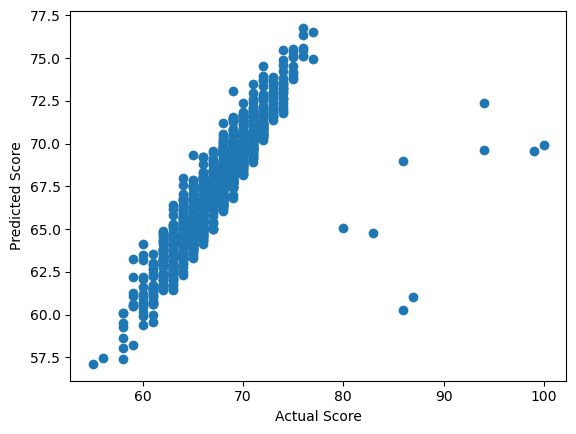

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.show()

Academic Score (Feature Engineering)

In [17]:
df["Support_Score"] = (
    df["Tutoring_Sessions"] +
    df["Attendance"] / 10 +
    df["Hours_Studied"])

In [18]:
df["Lifestyle_Score"] = (
    df["Sleep_Hours"] +
    df["Physical_Activity"])

In [19]:
df["Consistency_Index"] = (
    df["Hours_Studied"] * df["Attendance"])

In [20]:
df["Performance_Level"] = pd.cut(
    df["Exam_Score"],
    bins=[0,50,65,80,100],
    labels=["Poor","Average","Good","Excellent"])

In [21]:
df.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Support_Score,Lifestyle_Score,Consistency_Index,Performance_Level
0,23,84,1,0,0,7,73,1,1,0,...,3,0,1,2,1,67,31.4,10,1932,Good
1,19,64,1,2,0,8,59,1,1,2,...,4,0,0,1,0,61,27.4,12,1216,Average
2,24,98,2,2,1,7,91,2,1,2,...,4,0,2,2,1,74,35.8,11,2352,Good
3,29,89,1,2,1,8,98,2,1,1,...,4,0,1,1,1,71,38.9,12,2581,Good
4,19,92,2,2,1,6,65,2,1,3,...,4,0,0,2,0,70,31.2,10,1748,Good
5,19,88,2,2,1,8,89,2,1,3,...,3,0,2,2,1,71,30.8,11,1672,Good
6,29,84,2,1,1,7,68,1,1,1,...,2,0,1,1,1,67,38.4,9,2436,Good
7,25,78,1,0,1,6,50,2,1,1,...,2,0,1,0,1,66,33.8,8,1950,Good
8,17,94,2,0,0,6,80,0,1,0,...,1,0,0,2,1,69,26.4,7,1598,Good
9,23,98,2,2,1,8,71,2,1,0,...,5,0,1,1,1,72,32.8,13,2254,Good


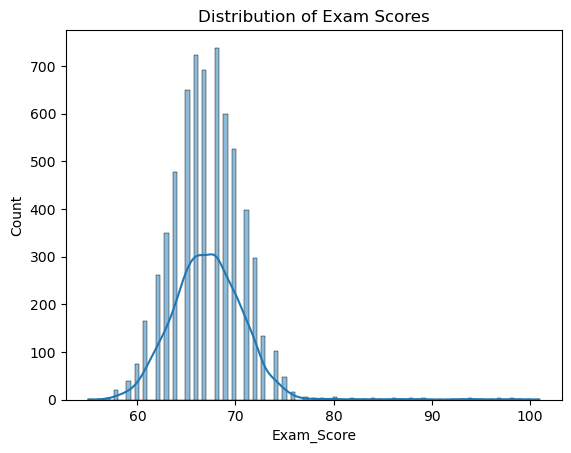

In [22]:
sns.histplot(df["Exam_Score"], kde=True)
plt.title("Distribution of Exam Scores")
plt.show()

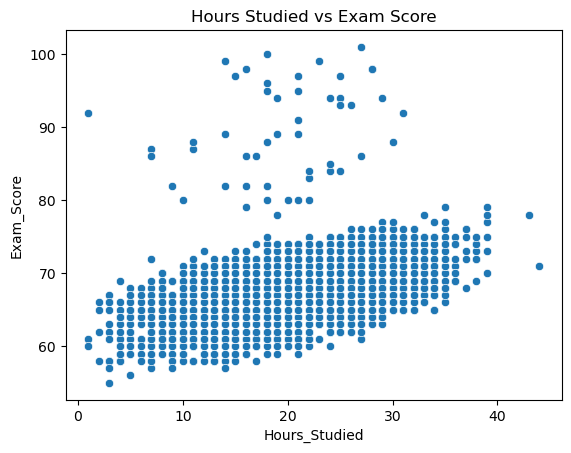

In [23]:
sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df)
plt.title("Hours Studied vs Exam Score")
plt.show()

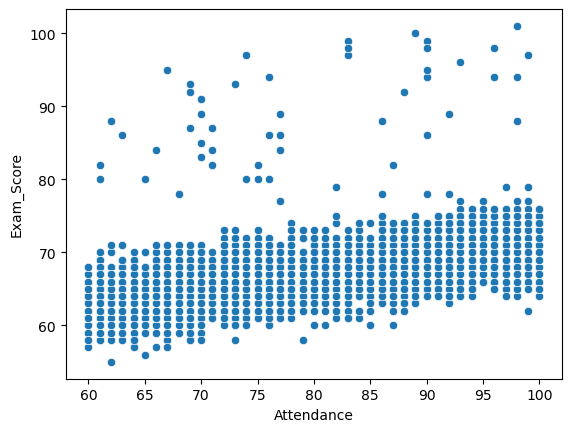

In [24]:
sns.scatterplot(x="Attendance", y="Exam_Score", data=df)
plt.show()

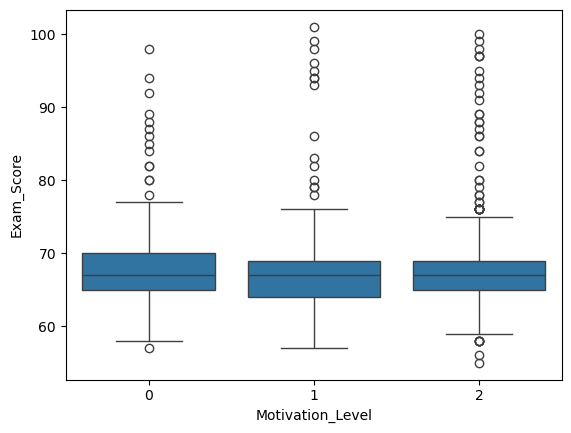

In [25]:
sns.boxplot(x="Motivation_Level", y="Exam_Score", data=df)
plt.show()

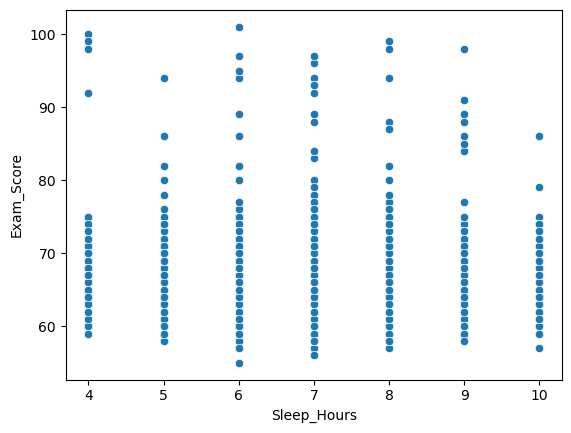

In [26]:
sns.scatterplot(x="Sleep_Hours", y="Exam_Score", data=df)
plt.show()

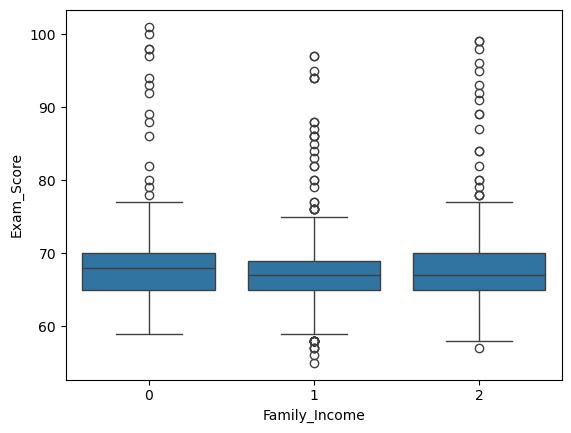

In [27]:
sns.boxplot(x="Family_Income", y="Exam_Score", data=df)
plt.show()

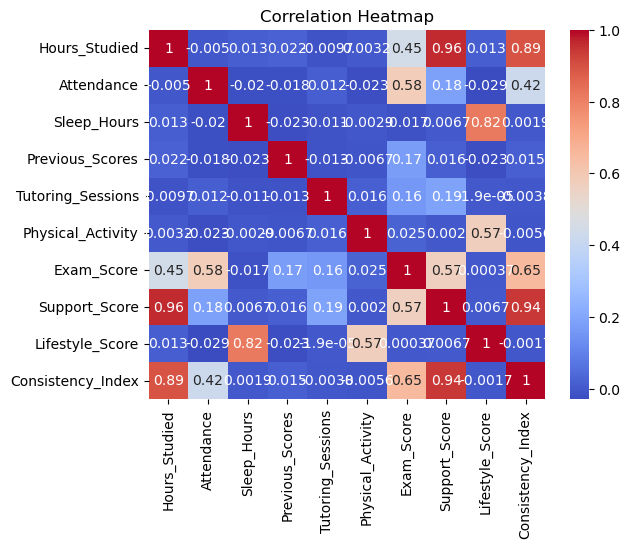

In [28]:
num = df.select_dtypes(include="number")

sns.heatmap(num.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [29]:
df.groupby("Gender")["Exam_Score"].mean()

Gender
0    67.274721
1    67.235629
Name: Exam_Score, dtype: float64

Females scored more

In [30]:
df.groupby("Tutoring_Sessions")["Exam_Score"].mean()

Tutoring_Sessions
0    66.506859
1    66.998579
2    67.556747
3    67.953750
4    68.239865
5    69.089109
6    71.666667
7    69.857143
8    69.000000
Name: Exam_Score, dtype: float64

In [31]:
from scipy.stats import ttest_ind

a = df[df["Tutoring_Sessions"] == 0]["Exam_Score"]
b = df[df["Tutoring_Sessions"] >= 3]["Exam_Score"]

ttest_ind(a, b)

TtestResult(statistic=np.float64(-11.187207550179556), pvalue=np.float64(1.9889743229575186e-28), df=np.float64(2679.0))

A two-sample t-test comparing students with no tutoring sessions against those with three or more sessions showed a statistically significant improvement in exam scores for tutored students (t = -11.19, p < 0.001).


In [32]:
df.groupby("Hours_Studied")["Exam_Score"].mean()

Hours_Studied
1     71.000000
2     62.750000
3     61.333333
4     61.875000
5     62.857143
6     63.470588
7     64.352941
8     64.200000
9     64.050633
10    64.373626
11    65.064286
12    64.740741
13    64.704225
14    65.591440
15    65.620462
16    66.204748
17    66.343243
18    67.030534
19    66.957647
20    66.957589
21    67.702381
22    67.484456
23    68.192802
24    68.250729
25    68.857651
26    68.694118
27    69.506912
28    69.644970
29    70.312977
30    70.689076
31    70.613333
32    70.944444
33    70.189189
34    70.592593
35    71.800000
36    71.300000
37    73.333333
38    72.714286
39    75.333333
43    78.000000
44    71.000000
Name: Exam_Score, dtype: float64

In [34]:
df.groupby("Attendance")["Exam_Score"].mean()

Attendance
60     62.364706
61     63.367742
62     63.719178
63     64.392157
64     63.846591
65     63.881579
66     64.492857
67     64.593407
68     65.114458
69     65.156627
70     65.493243
71     65.620000
72     65.718750
73     66.000000
74     66.327044
75     66.319444
76     66.888268
77     66.627119
78     66.911392
79     66.846154
80     67.147239
81     67.291925
82     67.351515
83     67.986842
84     67.828402
85     67.866197
86     68.657718
87     68.804054
88     68.941176
89     69.114650
90     70.019868
91     69.402367
92     69.740000
93     69.828221
94     69.554286
95     70.106250
96     70.554878
97     70.339869
98     70.685393
99     70.940000
100    70.848101
Name: Exam_Score, dtype: float64

In [52]:
import os

print(os.path.exists("model.pkl"))
print(os.path.exists("encoders.pkl"))

True
True


In [55]:
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Reload original dataset fresh
df = pd.read_csv("../Data/SPF.csv")

# Fill missing values
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Encode
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Train
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

# Save
pickle.dump(model, open("model.pkl","wb"))
pickle.dump(encoders, open("encoders.pkl","wb"))

print("Saved")
print("Encoded columns:", encoders.keys())

Saved
Encoded columns: dict_keys(['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender'])


In [56]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [57]:
print(encoders)
print(len(encoders))

{'Parental_Involvement': LabelEncoder(), 'Access_to_Resources': LabelEncoder(), 'Extracurricular_Activities': LabelEncoder(), 'Motivation_Level': LabelEncoder(), 'Internet_Access': LabelEncoder(), 'Family_Income': LabelEncoder(), 'Teacher_Quality': LabelEncoder(), 'School_Type': LabelEncoder(), 'Peer_Influence': LabelEncoder(), 'Learning_Disabilities': LabelEncoder(), 'Parental_Education_Level': LabelEncoder(), 'Distance_from_Home': LabelEncoder(), 'Gender': LabelEncoder()}
13
